In [37]:
# !unzip -q /content/archive.zip -d /content/intel_dataset

In [38]:
import os

for root, dirs, files in os.walk('/content/intel_dataset'):
    print(root)
    break

/content/intel_dataset


In [39]:
import os

for root, dirs, files in os.walk('/content/intel_dataset'):
    print(root)
    break

/content/intel_dataset


In [40]:
#!pip install tensorflow matplotlib seaborn scikit-learn streamlit

Step 1: Import Libraries

In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory

Step 2: Define Dataset Paths

In [42]:
base_path = "/content/intel_dataset"

for item in os.listdir(base_path):
    print(item)

seg_test
seg_pred
seg_train


In [43]:
train_dir = "/content/intel_dataset/seg_train/seg_train"
test_dir = "/content/intel_dataset/seg_test/seg_test"

Task 1: Dataset Exploration
Class Distribution

In [44]:
classes = os.listdir(train_dir)

counts = {}

for cls in classes:
    counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

df = pd.DataFrame({
    "Class": counts.keys(),
    "Count": counts.values()
})

df

,Class,Count
0,glacier,2404
1,sea,2274
2,mountain,2512
3,buildings,2191
4,street,2382
5,forest,2271


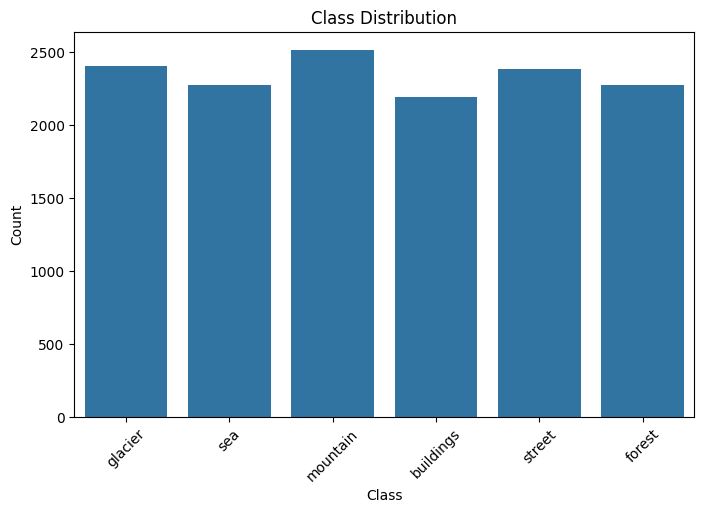

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Class", y="Count")
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

Display Sample Images

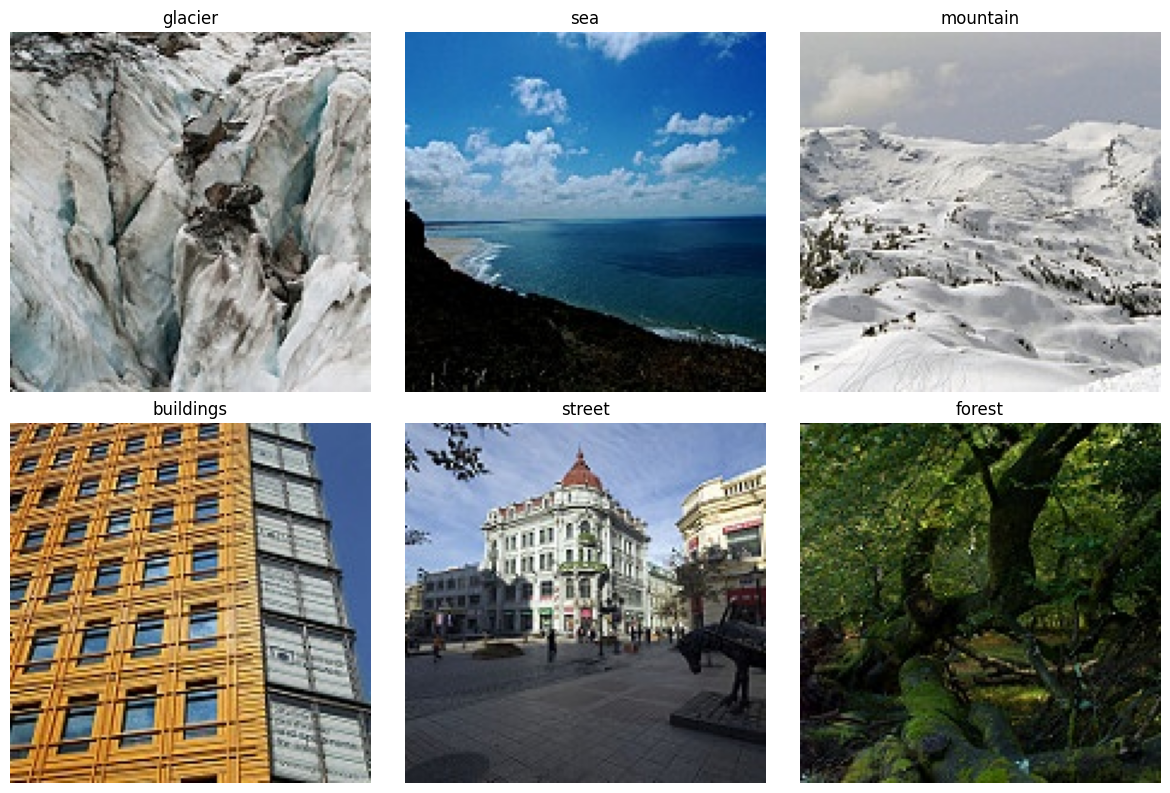

In [46]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    img_path = os.path.join(
        train_dir,
        cls,
        os.listdir(os.path.join(train_dir, cls))[0]
    )

    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

Create Train/Validation/Test Dataset

Image size:

In [47]:
IMG_SIZE = (150,150)
BATCH_SIZE = 32

Train dataset:

In [48]:
train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


Class names:

In [49]:
class_names = train_ds.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Analytical Question 1

Variations in lighting, viewpoint, and class distribution can affect the accuracy of satellite scene classification models. Changes in sunlight, shadows, weather conditions, and seasons can alter the appearance of the same scene, making classification more challenging.

Different viewpoints and distances may also cause the same scene category to look different across images. For example, glacier and mountain scenes can share similar visual features when captured from certain angles.

Based on the dataset exploration, the class distribution is relatively balanced, with class counts ranging from 2,191 to 2,512 images. Therefore, class imbalance is not expected to significantly impact model performance in this project.

Overall, lighting and viewpoint variations are likely to be the main challenges, while preprocessing and data augmentation can help improve the model's ability to generalize.

Task 2: Data Preprocessing and Augmentation

In [50]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

Normalize

In [51]:
normalization_layer = layers.Rescaling(1./255)

Optimize Pipeline

In [52]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## Analytical Question 2

Data augmentation helps reduce overfitting by generating different variations of the training images, allowing the model to learn more generalized features rather than memorizing specific examples.

In this project, horizontal flipping, rotation, zooming, and contrast adjustment were applied to the training images. These transformations simulate real-world variations in scene appearance and help the model become more robust to changes in orientation, scale, and lighting conditions.

As a result, the model is exposed to a wider variety of image patterns during training, which improves its ability to generalize to unseen data and reduces the risk of overfitting.

Task 3: CNN Design and Training
Baseline CNN

In [53]:
cnn_model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(150,150,3)),

    data_augmentation,

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(class_names),activation='softmax')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [54]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train

In [57]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=4
)

351/351 ━━━━━━━━━━━━━━━━━━━━ 705s 2s/step - accuracy: 0.5871 - loss: 1.0652 - val_accuracy: 0.6511 - val_loss: 0.8776


Plot Learning Curves

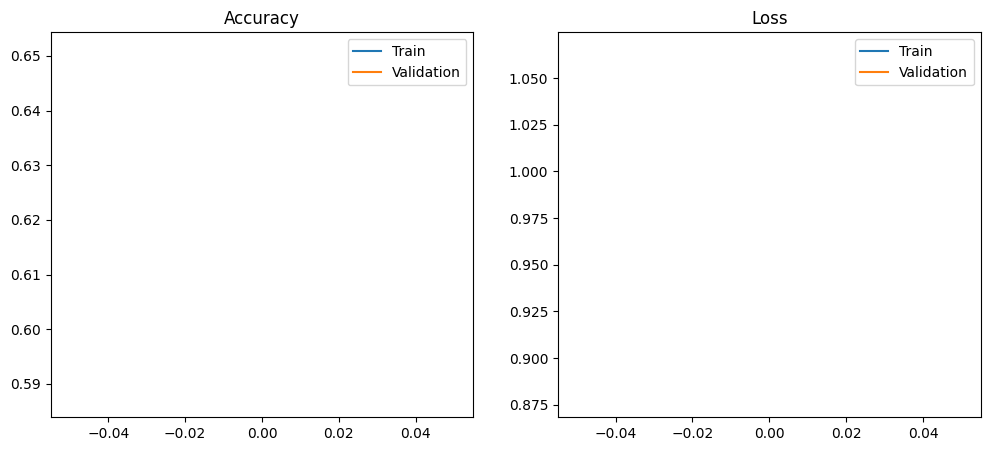

In [58]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title("Loss")

plt.show()

### Analytical Question 3

Convolution layers apply learnable filters to detect local patterns such as edges, textures, and shapes. As depth increases, the network learns increasingly complex features. Pooling layers reduce spatial dimensions, lowering computational cost and helping the model become more robust to small translations and distortions. Together, convolution and pooling enable hierarchical feature extraction.

Task 4: Model Evaluation

In [59]:
test_loss, test_acc = cnn_model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 50s 533ms/step - accuracy: 0.6520 - loss: 0.8917
Test Accuracy: 0.6520000100135803


Predictions

In [60]:
y_true = np.concatenate([
    y.numpy() for x, y in test_ds
])

pred_probs = cnn_model.predict(test_ds)

y_pred = np.argmax(pred_probs, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 434ms/step


Classification Report

In [61]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.45      0.75      0.57       437
      forest       0.92      0.84      0.88       474
     glacier       0.55      0.68      0.61       553
    mountain       0.74      0.54      0.63       525
         sea       0.78      0.30      0.43       510
      street       0.72      0.82      0.77       501

    accuracy                           0.65      3000
   macro avg       0.69      0.66      0.65      3000
weighted avg       0.69      0.65      0.64      3000



Confusion Matrix

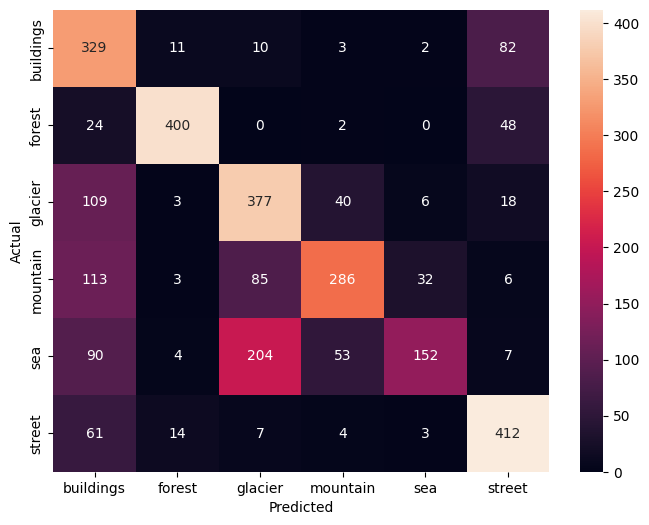

In [62]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Analytical Question 4

The model most frequently struggled with glacier, mountain, sea, and buildings scenes. Glacier and mountain images share similar visual features such as rocky terrain and snow-covered regions, making them difficult to distinguish. Buildings and street scenes also contain similar urban structures and roads, which can lead to misclassification.

The classification report shows that forest (F1-score: 0.88) and street (F1-score: 0.77) were classified more accurately, while sea (F1-score: 0.43) and buildings (F1-score: 0.57) were more challenging. These errors are mainly due to semantic and visual similarities between scene categories.

Task 5: Error Analysis

Collect Misclassified Images

In [63]:
images = []
true_labels = []

for img_batch, label_batch in test_ds:
    images.append(img_batch.numpy())
    true_labels.append(label_batch.numpy())

images = np.concatenate(images)
true_labels = np.concatenate(true_labels)

In [64]:
mis_idx = np.where(y_pred != true_labels)[0]

len(mis_idx)

1044

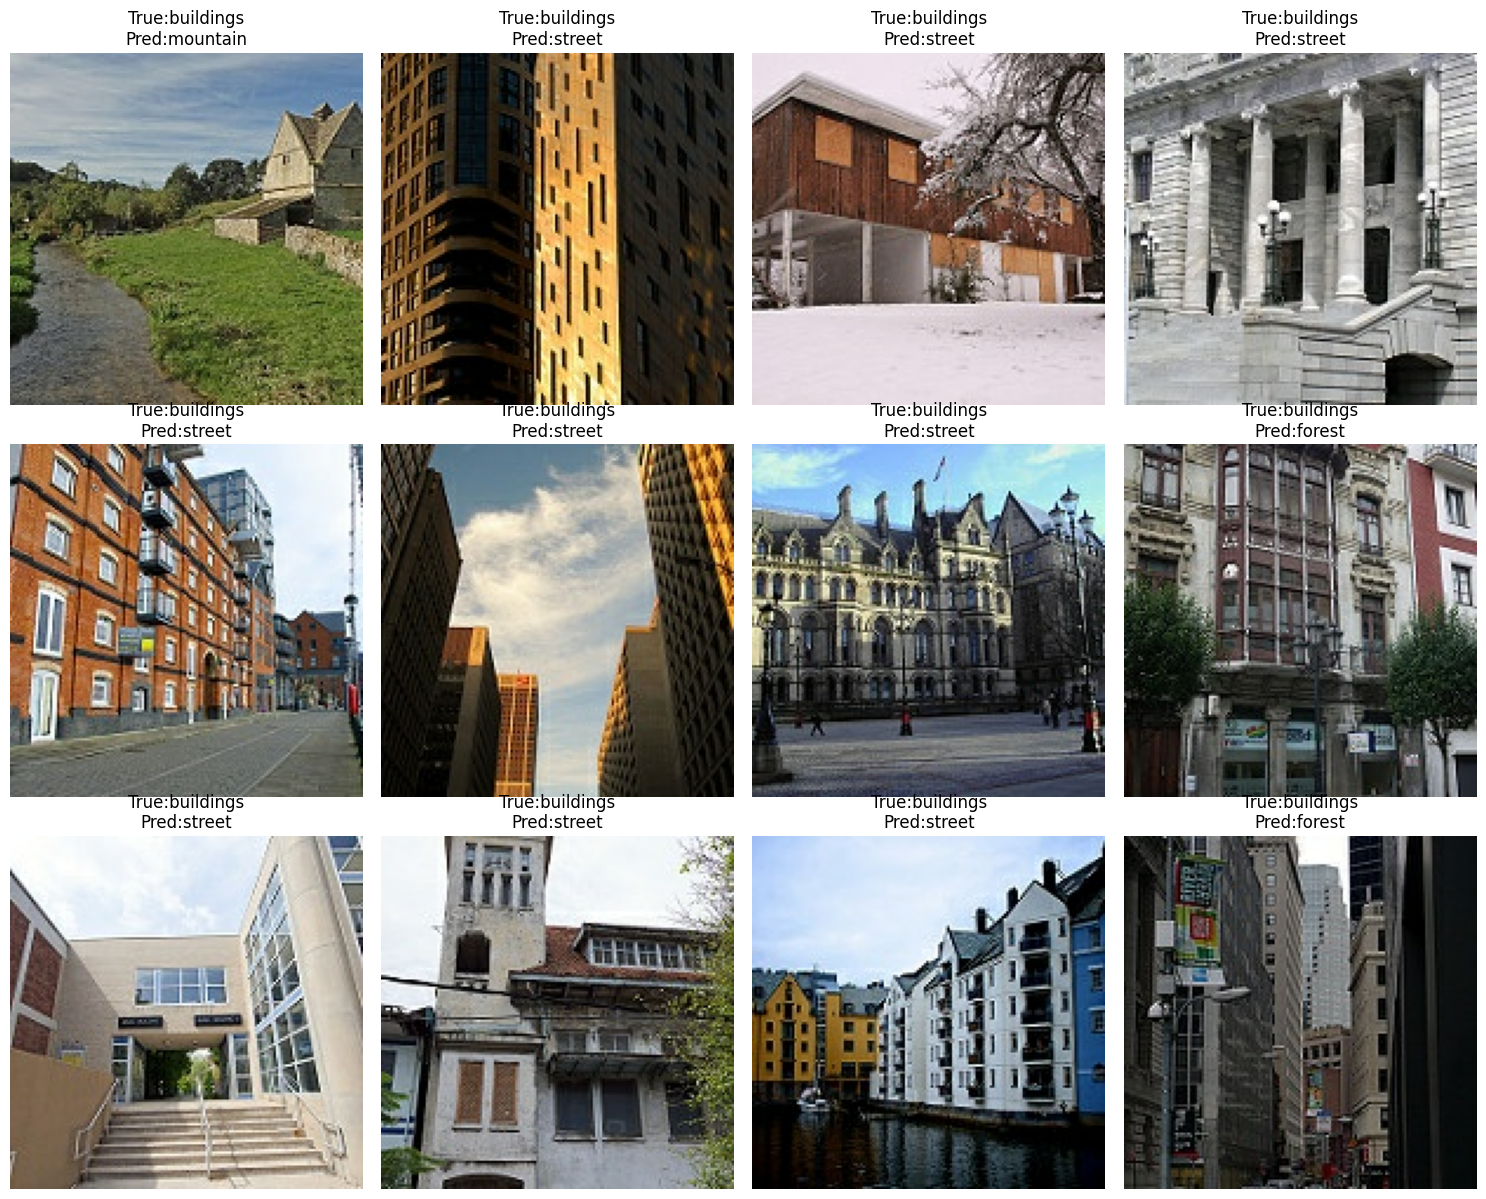

In [65]:
plt.figure(figsize=(15,12))

for i, idx in enumerate(mis_idx[:12]):

    plt.subplot(3,4,i+1)

    plt.imshow(images[idx].astype("uint8"))

    plt.title(
        f"True:{class_names[true_labels[idx]]}\nPred:{class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Analytical Question 5

The failure cases indicate that the model is often misled by visual similarities between classes. Glacier and mountain scenes share rocky and snow-covered features, while buildings and street scenes contain similar urban structures. Variations in lighting, shadows, and viewing angles also contribute to misclassification.

Overall, the model struggles when different scene categories have overlapping textures, colors, or structural patterns.

Task 6: Model Refinement (Transfer Learning)

This is where you get much better marks.

MobileNetV2

In [66]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150,150,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

/tmp/ipykernel_3311/2166839969.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Improved Model

In [67]:
inputs = tf.keras.Input(shape=(150,150,3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation='softmax'
)(x)

improved_model = tf.keras.Model(inputs, outputs)

Compile

In [68]:
improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train

In [ ]:
history2 = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 355s 977ms/step - accuracy: 0.7674 - loss: 0.6399 - val_accuracy: 0.8824 - val_loss: 0.3193
Epoch 2/5
304/351 ━━━━━━━━━━━━━━━━━━━━ 37s 793ms/step - accuracy: 0.8440 - loss: 0.4540

In [ ]:
loss, acc = improved_model.evaluate(test_ds)

print("Improved Accuracy:", acc)

### Analytical Question 6

The transfer learning model achieved higher accuracy and faster convergence compared to the baseline CNN. Pretrained features extracted from ImageNet provided better generalization. However, this improvement comes at the cost of increased model complexity, larger memory requirements, and potentially longer inference times.

In [ ]:
improved_model.save("intel_scene_classifier.h5")

In [ ]:
from google.colab import files

files.download("intel_scene_classifier.h5")